# Análisis de Features de Clasificación de Frutas

Este notebook extrae y visualiza los features de cada imagen en la carpeta `data/` usando la clase `Image` del proyecto.

**Features extraídos por imagen:**
- 2 Hu Moments
- 256 valores de Histograma Hue
- 256 valores de Histograma Saturación
- 1 Circularidad
- 1 Compacidad
- **Total: 516 valores por imagen**

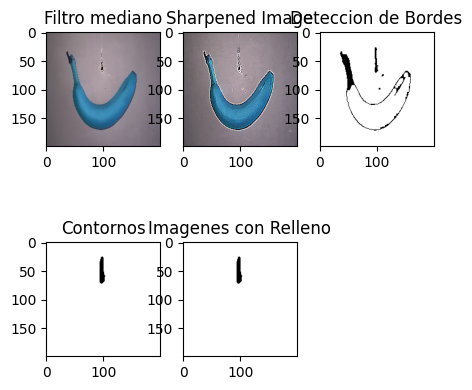

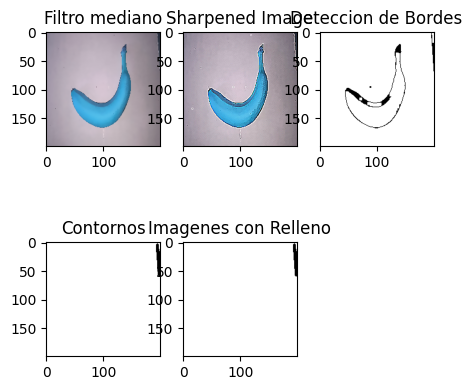

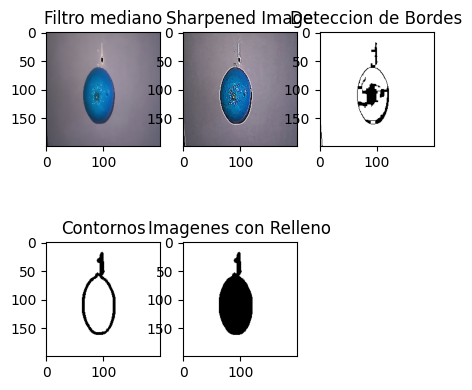

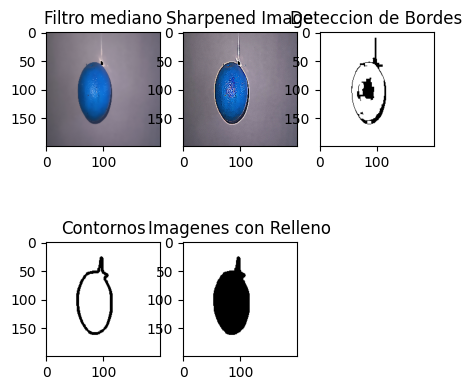

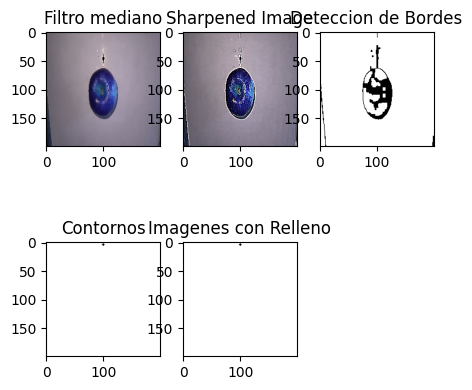

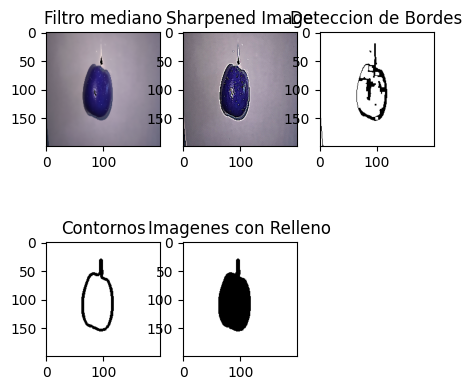

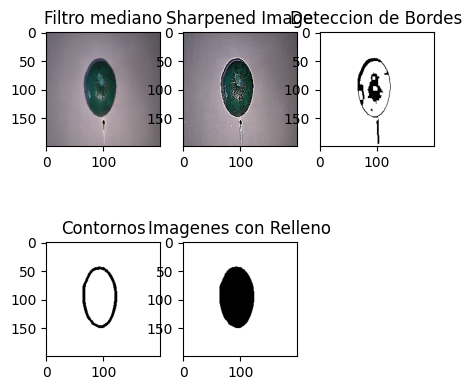

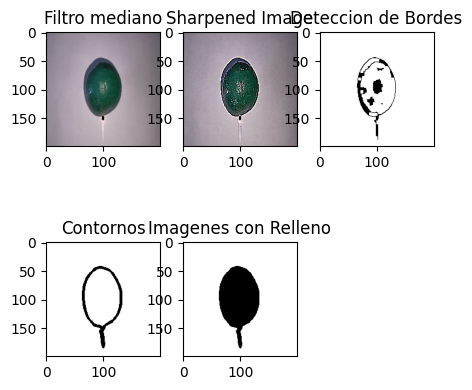

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Importar la clase Image
import sys
sys.path.append('/home/bruno/fing/IA_I')
from image2 import Image

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(42)

## 1. Cargar y Explorar Imágenes desde Carpetas

In [2]:
# Explorar estructura de carpetas
base_folder = '/home/bruno/fing/IA_I/data'

# Listar carpetas de frutas
fruit_folders = {}
for folder in os.listdir(base_folder):
    folder_path = os.path.join(base_folder, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))]
        fruit_folders[folder] = images
        print(f"📁 {folder}: {len(images)} imágenes")

print(f"\n✅ Total de carpetas: {len(fruit_folders)}")
print(f"Total de imágenes: {sum(len(imgs) for imgs in fruit_folders.values())}")

📁 naranja: 4 imágenes
📁 naranja_sin_fondo: 4 imágenes
📁 manzana: 4 imágenes
📁 zapallo: 4 imágenes
📁 manzana_sin_fondo: 4 imágenes
📁 zapallo_sin_fondo: 4 imágenes
📁 banana: 4 imágenes
📁 banana_sin_fondo: 4 imágenes

✅ Total de carpetas: 8
Total de imágenes: 32


## 2. Extraer Features de Todas las Imágenes

In [3]:
# Extraer features de todas las imágenes
all_features = []
all_labels = []
all_images = []

for fruit_type, images in fruit_folders.items():
    print(f"\n🍎 Procesando {fruit_type}...")
    for img_name in images:
        img_path = os.path.join(base_folder, fruit_type, img_name)
        try:
            # Crear instancia de Image y extraer features
            img_obj = Image(img_path)
            features = img_obj.get_features()
            
            all_features.append(features)
            all_labels.append(fruit_type)
            all_images.append((img_path, fruit_type, img_name))
            
            print(f"  ✓ {img_name}: {len(features)} features extraídos")
        except Exception as e:
            print(f"  ✗ Error en {img_name}: {e}")

print(f"\n✅ Total de imágenes procesadas: {len(all_features)}")
print(f"✅ Features por imagen: {len(all_features[0]) if all_features else 'N/A'}")


🍎 Procesando naranja...
  ✓ naranja1.jpg: 516 features extraídos
  ✓ naranja2.jpg: 516 features extraídos
  ✓ naranja4.jpg: 516 features extraídos
  ✓ naranja3.jpg: 516 features extraídos

🍎 Procesando naranja_sin_fondo...
  ✓ naranja3.png: 516 features extraídos
  ✓ naranja2.png: 516 features extraídos
  ✓ naranja4.png: 516 features extraídos
  ✓ naranja1.png: 516 features extraídos

🍎 Procesando manzana...
  ✓ manzana3.jpg: 516 features extraídos
  ✓ manzana1.jpg: 516 features extraídos
  ✓ manzana4.jpg: 516 features extraídos
  ✓ manzana2.jpg: 516 features extraídos

🍎 Procesando zapallo...
  ✓ zapallo4.jpg: 516 features extraídos
  ✓ zapallo2.jpg: 516 features extraídos
  ✓ zapallo1.jpg: 516 features extraídos
  ✓ zapallo3.jpg: 516 features extraídos

🍎 Procesando manzana_sin_fondo...
  ✓ manzana1.png: 516 features extraídos
  ✓ manzana4.png: 516 features extraídos
  ✓ manzana2.png: 516 features extraídos
  ✓ manzana3.png: 516 features extraídos

🍎 Procesando zapallo_sin_fondo...


## 3. Desglosar Features por Componente

In [4]:
# Convertir a array de numpy
features_array = np.array(all_features)

# Desglosar los componentes del vector de features
# Estructura: 2 Hu Moments + 256 Hue + 256 Saturación + 1 Circularidad + 1 Compacidad = 516
hu_moments = features_array[:, :2]
hist_hue = features_array[:, 2:258]
hist_saturation = features_array[:, 258:514]
circularity = features_array[:, 514]
compactness = features_array[:, 515]

print("📊 Desglose de Features:")
print(f"  - Hu Moments: {hu_moments.shape} (2 valores)")
print(f"  - Histograma Hue: {hist_hue.shape} (256 valores)")
print(f"  - Histograma Saturación: {hist_saturation.shape} (256 valores)")
print(f"  - Circularidad: {circularity.shape} (1 valor)")
print(f"  - Compacidad: {compactness.shape} (1 valor)")
print(f"  - Total: {features_array.shape}")

# Crear DataFrame con valores agregados
data_simple = pd.DataFrame({
    'Imagen': [img[2] for img in all_images],
    'Fruta': all_labels,
    'Hu_1': hu_moments[:, 0],
    'Hu_3': hu_moments[:, 1],
    'Circularidad': circularity,
    'Compacidad': compactness,
    'Hue_promedio': np.mean(hist_hue, axis=1),
    'Saturacion_promedio': np.mean(hist_saturation, axis=1)
})

print("\n📋 Primeras 5 muestras:")
print(data_simple.head())

📊 Desglose de Features:
  - Hu Moments: (32, 2) (2 valores)
  - Histograma Hue: (32, 256) (256 valores)
  - Histograma Saturación: (32, 256) (256 valores)
  - Circularidad: (32,) (1 valor)
  - Compacidad: (32,) (1 valor)
  - Total: (32, 516)

📋 Primeras 5 muestras:
         Imagen              Fruta      Hu_1      Hu_3  Circularidad  \
0  naranja1.jpg            naranja -0.286785 -0.938637     -0.031388   
1  naranja2.jpg            naranja -0.291619 -0.938870     -0.020944   
2  naranja4.jpg            naranja -0.291832 -0.938824     -0.020825   
3  naranja3.jpg            naranja -0.287792 -0.911042      0.231129   
4  naranja3.png  naranja_sin_fondo -0.295248 -0.939546     -0.007920   

   Compacidad  Hue_promedio  Saturacion_promedio  
0    0.134566      0.001262             0.001836  
1    0.124146      0.001308             0.001788  
2    0.124021      0.001444             0.001662  
3   -0.130987      0.001250             0.001589  
4    0.111196      0.000423             0.0004

## 4. Estadísticas por Fruta/Verdura

In [5]:
# Estadísticas por fruta
print("📊 ESTADÍSTICAS POR FRUTA/VERDURA\n")

for fruit in sorted(data_simple['Fruta'].unique()):
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    print(f"\n{'='*60}")
    print(f"🍎 {fruit.upper()}")
    print(f"{'='*60}")
    print(f"Imágenes: {len(fruit_data)}\n")
    
    stats_cols = ['Hu_1', 'Hu_3', 'Circularidad', 'Compacidad', 'Hue_promedio', 'Saturacion_promedio']
    
    for col in stats_cols:
        values = fruit_data[col]
        print(f"{col:20} | Media: {values.mean():8.5f} | Std: {values.std():8.5f} | Min: {values.min():8.5f} | Max: {values.max():8.5f}")

📊 ESTADÍSTICAS POR FRUTA/VERDURA


🍎 BANANA
Imágenes: 4

Hu_1                 | Media: -0.25464 | Std:  0.01176 | Min: -0.26501 | Max: -0.23773
Hu_3                 | Media: -0.94882 | Std:  0.00802 | Min: -0.95852 | Max: -0.94143
Circularidad         | Media:  0.01607 | Std:  0.07650 | Min: -0.05038 | Max:  0.09190
Compacidad           | Media:  0.08827 | Std:  0.07568 | Min:  0.01279 | Max:  0.15406
Hue_promedio         | Media:  0.00151 | Std:  0.00010 | Min:  0.00142 | Max:  0.00163
Saturacion_promedio  | Media:  0.00135 | Std:  0.00010 | Min:  0.00125 | Max:  0.00148

🍎 BANANA_SIN_FONDO
Imágenes: 4

Hu_1                 | Media: -0.26716 | Std:  0.00738 | Min: -0.27328 | Max: -0.25809
Hu_3                 | Media: -0.94052 | Std:  0.00181 | Min: -0.94267 | Max: -0.93857
Circularidad         | Media: -0.05066 | Std:  0.00219 | Min: -0.05216 | Max: -0.04746
Compacidad           | Media:  0.15406 | Std:  0.00227 | Min:  0.15075 | Max:  0.15579
Hue_promedio         | Media:  0.00043 |

## 5. Gráficos Comparativos: Circularidad y Compacidad

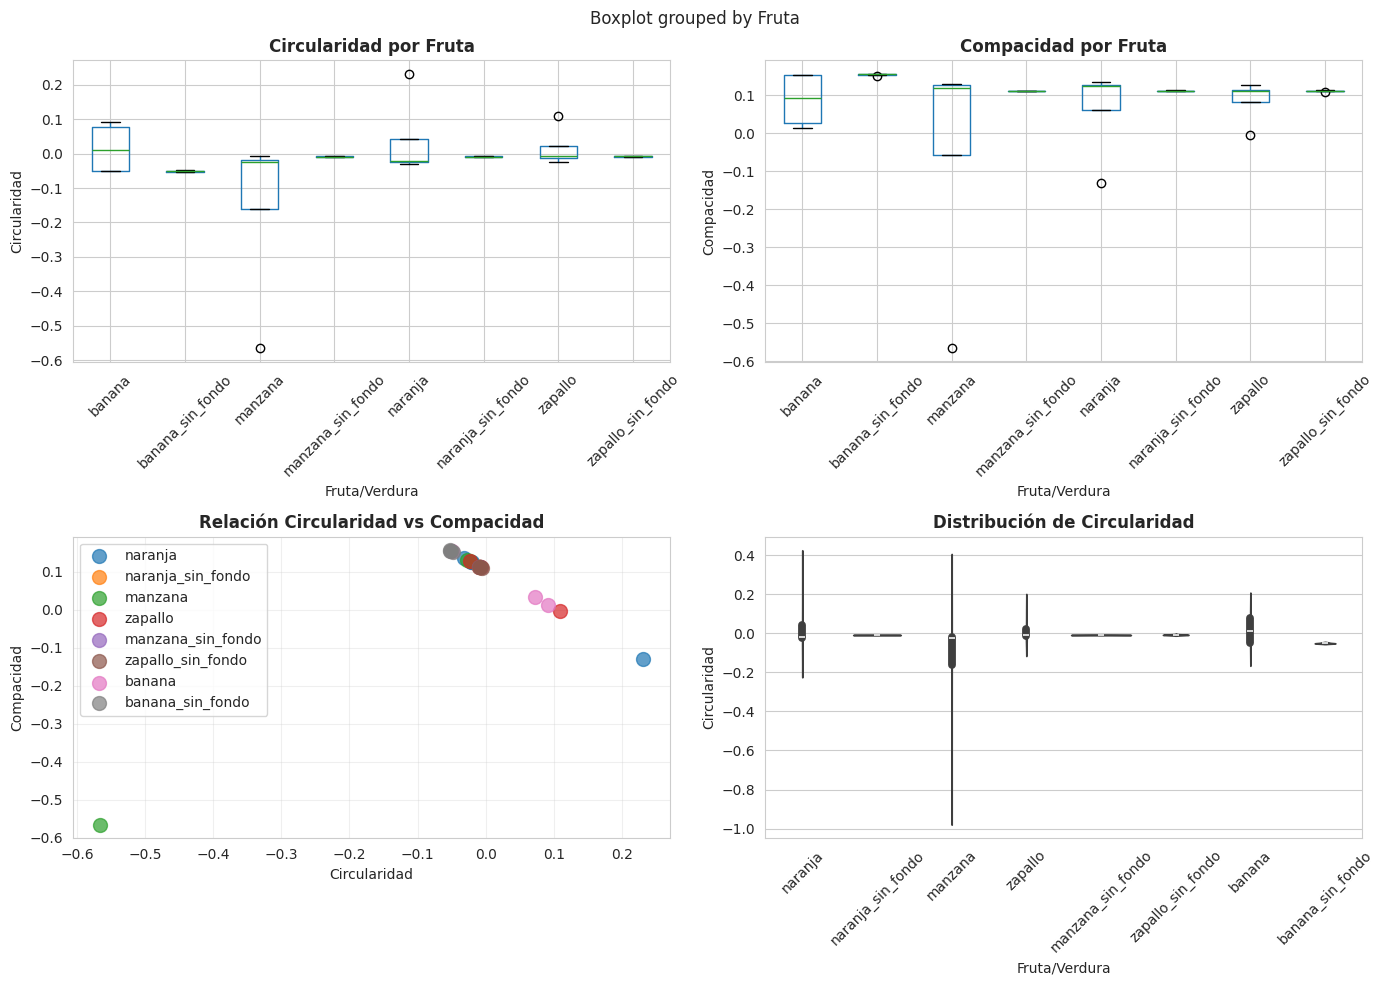

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot - Circularidad
ax1 = axes[0, 0]
data_simple.boxplot(column='Circularidad', by='Fruta', ax=ax1)
ax1.set_title('Circularidad por Fruta', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fruta/Verdura')
ax1.set_ylabel('Circularidad')
plt.sca(ax1)
plt.xticks(rotation=45)

# 2. Box plot - Compacidad
ax2 = axes[0, 1]
data_simple.boxplot(column='Compacidad', by='Fruta', ax=ax2)
ax2.set_title('Compacidad por Fruta', fontsize=12, fontweight='bold')
ax2.set_xlabel('Fruta/Verdura')
ax2.set_ylabel('Compacidad')
plt.sca(ax2)
plt.xticks(rotation=45)

# 3. Scatter plot - Circularidad vs Compacidad
ax3 = axes[1, 0]
for fruit in data_simple['Fruta'].unique():
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    ax3.scatter(fruit_data['Circularidad'], fruit_data['Compacidad'], 
               label=fruit, s=100, alpha=0.7)
ax3.set_xlabel('Circularidad')
ax3.set_ylabel('Compacidad')
ax3.set_title('Relación Circularidad vs Compacidad', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Violin plot - Circularidad
ax4 = axes[1, 1]
sns.violinplot(data=data_simple, x='Fruta', y='Circularidad', ax=ax4)
ax4.set_title('Distribución de Circularidad', fontsize=12, fontweight='bold')
ax4.set_xlabel('Fruta/Verdura')
ax4.set_ylabel('Circularidad')
plt.sca(ax4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Gráficos de Histogramas Hue y Saturación

IndexError: list index out of range

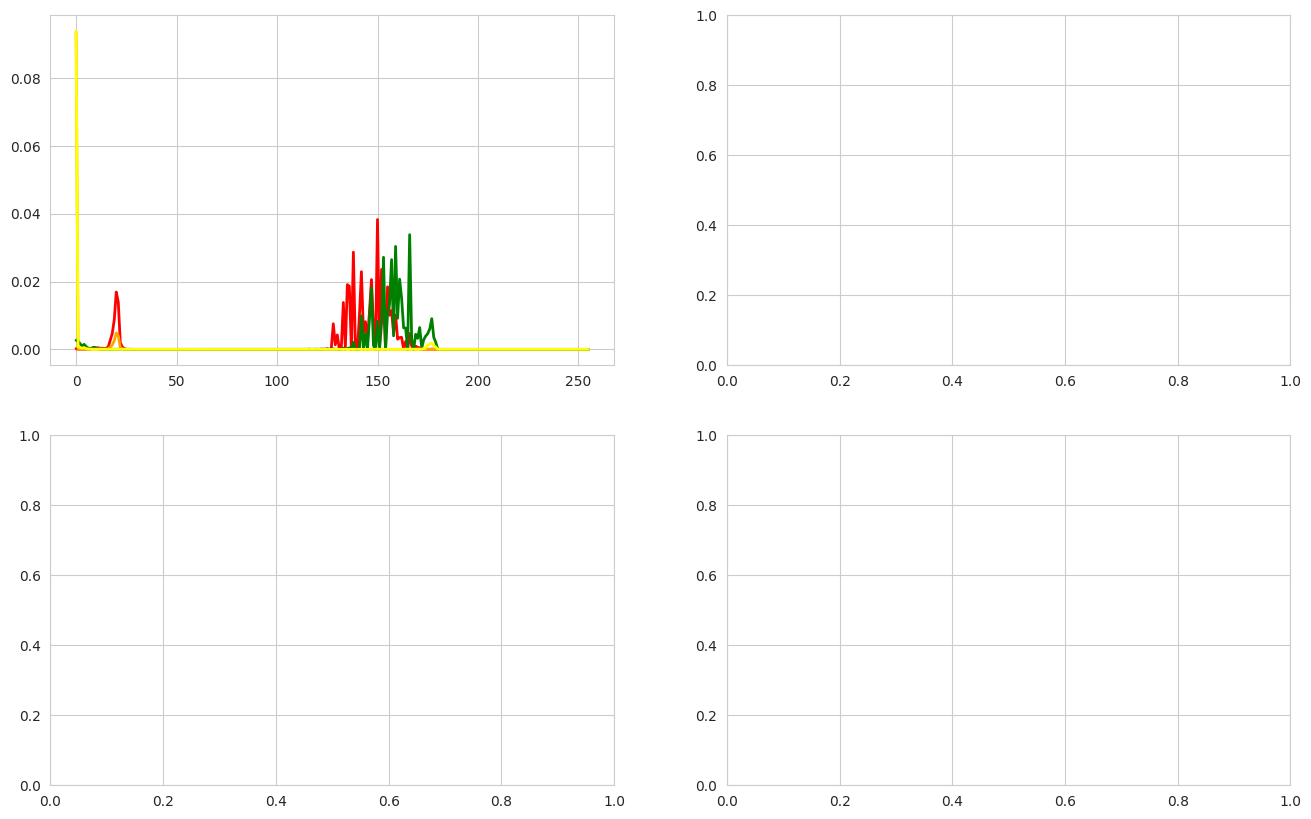

In [7]:
# Promediar histogramas por fruta
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fruits = sorted(data_simple['Fruta'].unique())
colors = ['red', 'orange', 'green', 'yellow']

# Histograma Hue promedio por fruta
ax1 = axes[0, 0]
for i, fruit in enumerate(fruits):
    fruit_indices = np.where(np.array(all_labels) == fruit)[0]
    hue_avg = np.mean(hist_hue[fruit_indices], axis=0)
    ax1.plot(hue_avg, label=fruit, linewidth=2, color=colors[i])

ax1.set_xlabel('Hue Value (0-180°)')
ax1.set_ylabel('Frecuencia Normalizada')
ax1.set_title('Histograma Hue Promedio por Fruta', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histograma Saturación promedio por fruta
ax2 = axes[0, 1]
for i, fruit in enumerate(fruits):
    fruit_indices = np.where(np.array(all_labels) == fruit)[0]
    sat_avg = np.mean(hist_saturation[fruit_indices], axis=0)
    ax2.plot(sat_avg, label=fruit, linewidth=2, color=colors[i])

ax2.set_xlabel('Saturación Value (0-255)')
ax2.set_ylabel('Frecuencia Normalizada')
ax2.set_title('Histograma Saturación Promedio por Fruta', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Box plot - Hue promedio
ax3 = axes[1, 0]
data_simple.boxplot(column='Hue_promedio', by='Fruta', ax=ax3)
ax3.set_title('Hue Promedio por Fruta', fontsize=12, fontweight='bold')
ax3.set_xlabel('Fruta/Verdura')
ax3.set_ylabel('Hue Promedio')
plt.sca(ax3)
plt.xticks(rotation=45)

# Box plot - Saturación promedio
ax4 = axes[1, 1]
data_simple.boxplot(column='Saturacion_promedio', by='Fruta', ax=ax4)
ax4.set_title('Saturación Promedio por Fruta', fontsize=12, fontweight='bold')
ax4.set_xlabel('Fruta/Verdura')
ax4.set_ylabel('Saturación Promedio')
plt.sca(ax4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Comparación de Hu Moments

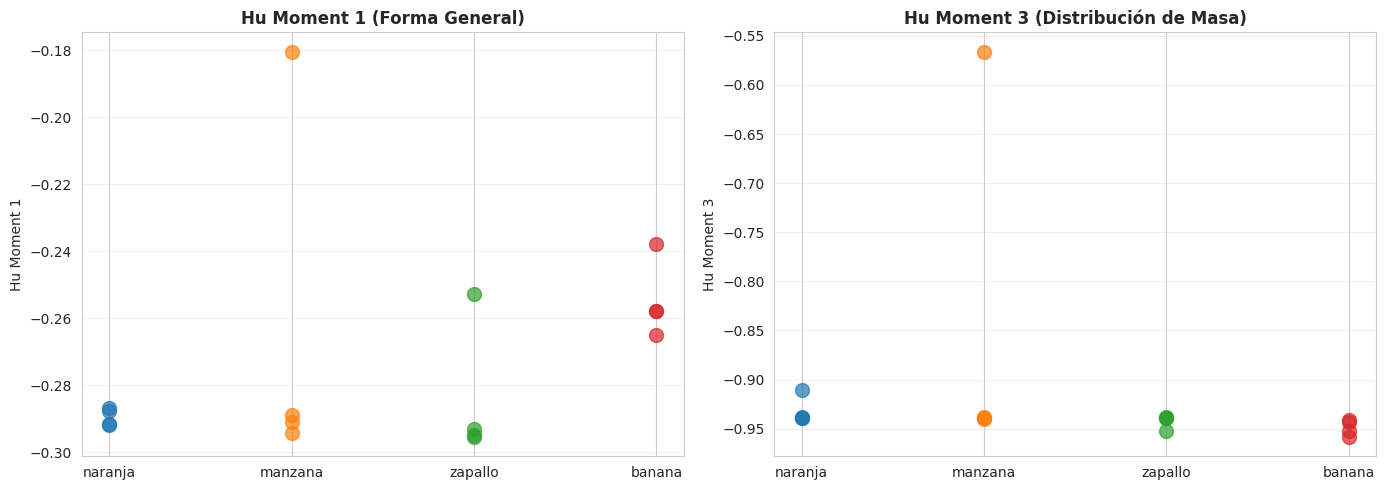


📊 TABLA COMPARATIVA: HU MOMENTS POR FRUTA

             Hu_1                                    Hu_3                      \
             mean       std       min       max      mean       std       min   
Fruta                                                                           
banana  -0.254636  0.011758 -0.265010 -0.237731 -0.948815  0.008023 -0.958519   
manzana -0.263704  0.055583 -0.294468 -0.180398 -0.845758  0.186510 -0.939751   
naranja -0.289507  0.002596 -0.291832 -0.286785 -0.931844  0.013868 -0.938870   
zapallo -0.284106  0.020899 -0.295520 -0.252795 -0.942286  0.006478 -0.951938   

                   
              max  
Fruta              
banana  -0.941426  
manzana -0.565995  
naranja -0.911042  
zapallo -0.938020  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hu moment 1 por fruta
ax1 = axes[0]
for fruit in data_simple['Fruta'].unique():
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    ax1.scatter([fruit] * len(fruit_data), fruit_data['Hu_1'], s=100, alpha=0.7, label=fruit)

ax1.set_ylabel('Hu Moment 1')
ax1.set_title('Hu Moment 1 (Forma General)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Hu moment 3 por fruta
ax2 = axes[1]
for fruit in data_simple['Fruta'].unique():
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    ax2.scatter([fruit] * len(fruit_data), fruit_data['Hu_3'], s=100, alpha=0.7)

ax2.set_ylabel('Hu Moment 3')
ax2.set_title('Hu Moment 3 (Distribución de Masa)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla comparativa
print("\n📊 TABLA COMPARATIVA: HU MOMENTS POR FRUTA\n")
summary = data_simple.groupby('Fruta')[['Hu_1', 'Hu_3']].agg(['mean', 'std', 'min', 'max'])
print(summary)

## 8. Visualizar Imágenes con sus Features

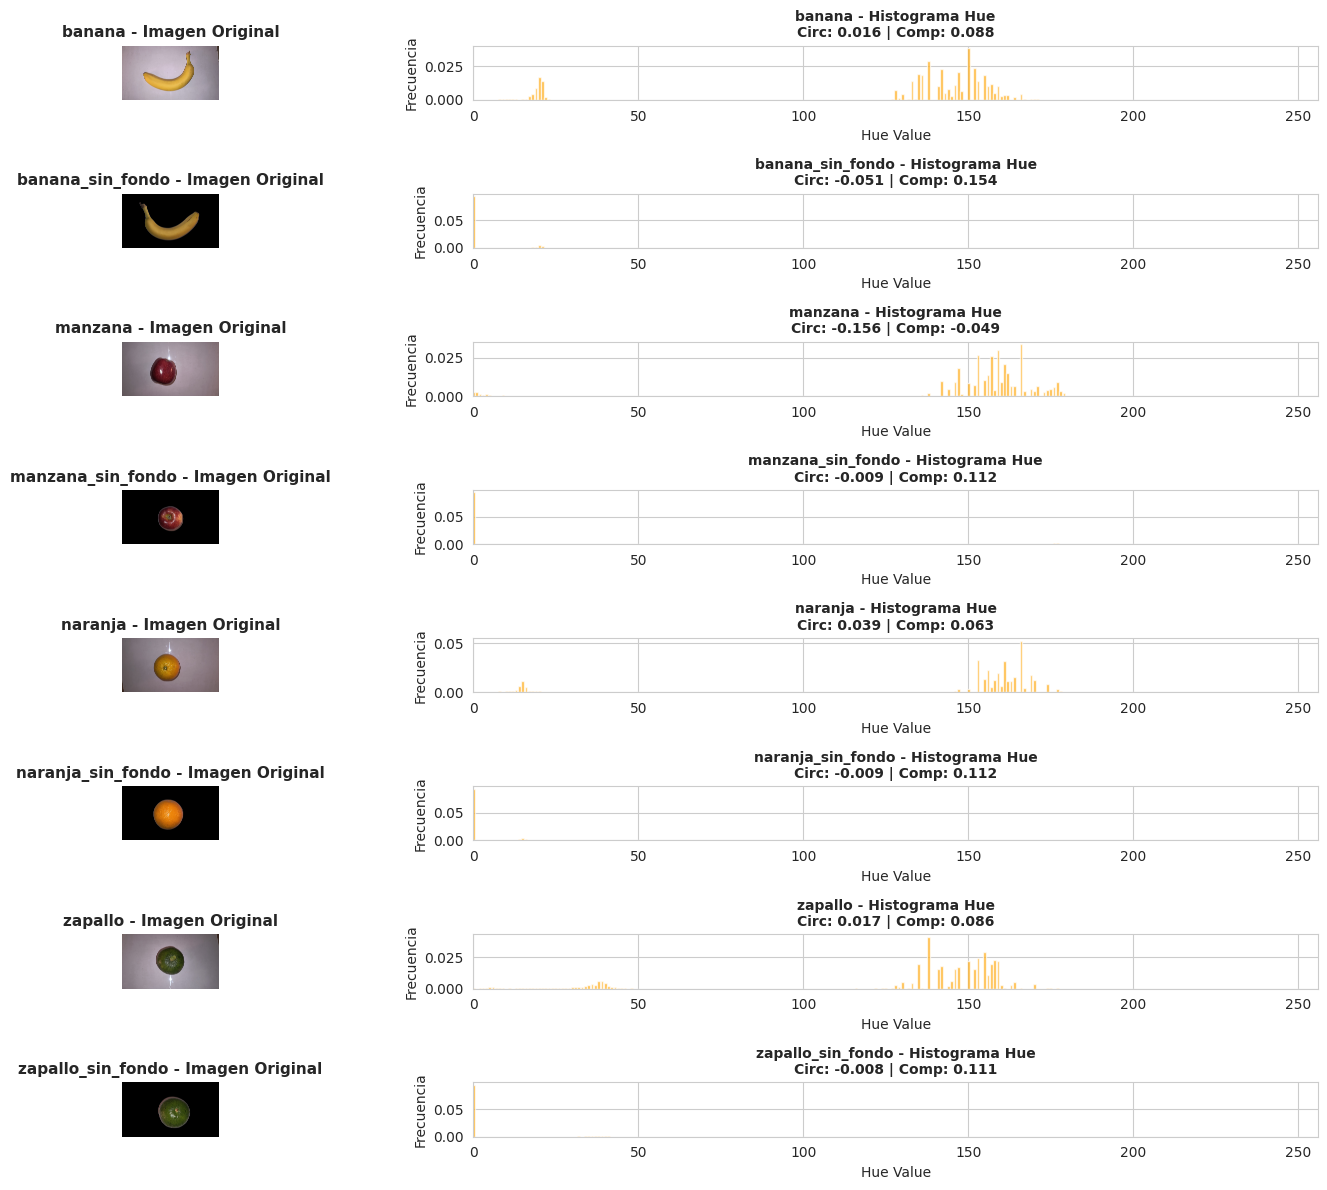

In [8]:
# Mostrar una imagen de cada fruta con sus features
fig = plt.figure(figsize=(16, 12))

fruits = sorted(data_simple['Fruta'].unique())

for idx, fruit in enumerate(fruits):
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    first_img_info = all_images[data_simple[data_simple['Fruta'] == fruit].index[0]]
    img_path = first_img_info[0]
    
    # Cargar y mostrar imagen
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Subplot para imagen
    ax_img = plt.subplot(len(fruits), 2, idx*2 + 1)
    ax_img.imshow(img_rgb)
    ax_img.set_title(f'{fruit} - Imagen Original', fontsize=11, fontweight='bold')
    ax_img.axis('off')
    
    # Subplot para histograma Hue
    ax_hist = plt.subplot(len(fruits), 2, idx*2 + 2)
    
    fruit_indices = np.where(np.array(all_labels) == fruit)[0]
    hue_avg = np.mean(hist_hue[fruit_indices], axis=0)
    
    ax_hist.bar(range(256), hue_avg, color='orange', alpha=0.7)
    ax_hist.set_title(f'{fruit} - Histograma Hue\nCirc: {fruit_data["Circularidad"].mean():.3f} | Comp: {fruit_data["Compacidad"].mean():.3f}', 
                     fontsize=10, fontweight='bold')
    ax_hist.set_xlabel('Hue Value')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.set_xlim([0, 256])

plt.tight_layout()
plt.show()

## 9. Heatmap de Correlaciones entre Features

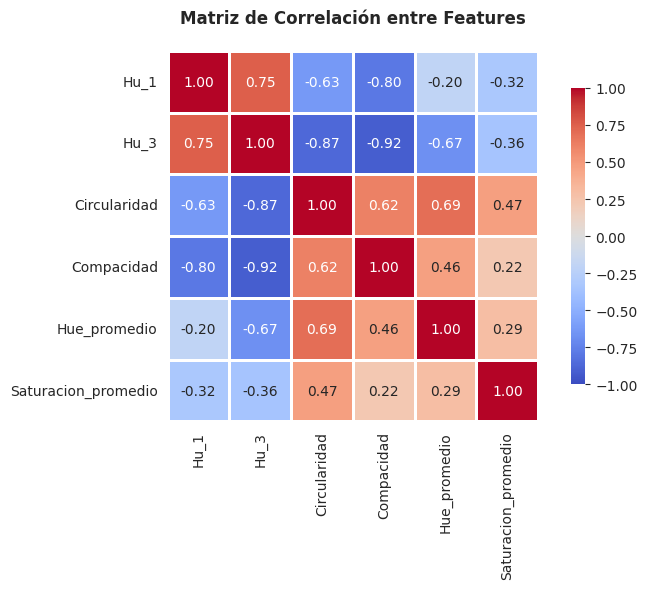

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Calcular correlación entre features principales
correlation_cols = ['Hu_1', 'Hu_3', 'Circularidad', 'Compacidad', 'Hue_promedio', 'Saturacion_promedio']
correlation_matrix = data_simple[correlation_cols].corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Matriz de Correlación entre Features', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 10. Resumen de Discriminación entre Clases

En esta sección se analiza cuáles features son más útiles para distinguir entre frutas/verduras.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Preparar datos normalizados
features_to_analyze = data_simple[['Hu_1', 'Hu_3', 'Circularidad', 'Compacidad', 'Hue_promedio', 'Saturacion_promedio']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_to_analyze)

# Convertir etiquetas a números
fruit_to_num = {fruit: i for i, fruit in enumerate(sorted(data_simple['Fruta'].unique()))}
labels_num = np.array([fruit_to_num[f] for f in data_simple['Fruta']])

# Calcular silhueta score (mide qué tan bien separadas están las clases)
silhouette_avg = silhouette_score(features_scaled, labels_num)

print("\n" + "="*70)
print("📊 ANÁLISIS DE DISCRIMINACIÓN ENTRE FRUTAS")
print("="*70)
print(f"\nSilhouette Score: {silhouette_avg:.4f}")
print("(Rango: -1 a 1, valores más altos = mejor separación)")

# Distancias entre centros de clases
print("\n📍 CENTROS DE CLASES (valores normalizados):\n")
for fruit in sorted(data_simple['Fruta'].unique()):
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    fruit_idx = [fruit_to_num[f] for f in data_simple['Fruta'] if f == fruit]
    centroid = features_scaled[labels_num == fruit_to_num[fruit]].mean(axis=0)
    print(f"{fruit:12} | Hu1: {centroid[0]:7.3f} | Hu3: {centroid[1]:7.3f} | Circ: {centroid[2]:7.3f} | Comp: {centroid[3]:7.3f}")

# Calcular distancias entre centros
print("\n📏 DISTANCIAS EUCLIDIANAS ENTRE CENTROS DE CLASES:\n")
fruits_sorted = sorted(data_simple['Fruta'].unique())
centroids = {}
for fruit in fruits_sorted:
    fruit_idx = labels_num == fruit_to_num[fruit]
    centroids[fruit] = features_scaled[fruit_idx].mean(axis=0)

# Tabla de distancias
distances_df = pd.DataFrame(index=fruits_sorted, columns=fruits_sorted)
for fruit1 in fruits_sorted:
    for fruit2 in fruits_sorted:
        dist = np.linalg.norm(centroids[fruit1] - centroids[fruit2])
        distances_df.loc[fruit1, fruit2] = f"{dist:.3f}"

print(distances_df)


📊 ANÁLISIS DE DISCRIMINACIÓN ENTRE FRUTAS

Silhouette Score: 0.0196
(Rango: -1 a 1, valores más altos = mejor separación)

📍 CENTROS DE CLASES (valores normalizados):

banana       | Hu1:   0.614 | Hu3:  -0.347 | Circ:   0.233 | Comp:   0.237
manzana      | Hu1:   0.311 | Hu3:   0.783 | Circ:  -0.856 | Comp:  -0.553
naranja      | Hu1:  -0.553 | Hu3:  -0.161 | Circ:   0.381 | Comp:   0.091
zapallo      | Hu1:  -0.372 | Hu3:  -0.275 | Circ:   0.242 | Comp:   0.224

📏 DISTANCIAS EUCLIDIANAS ENTRE CENTROS DE CLASES:

        banana manzana naranja zapallo
banana   0.000   2.245   2.275   1.042
manzana  2.245   0.000   2.321   2.135
naranja  2.275   2.321   0.000   1.868
zapallo  1.042   2.135   1.868   0.000


## 11. Visualización 3D: Circularidad vs Compacidad vs Hue

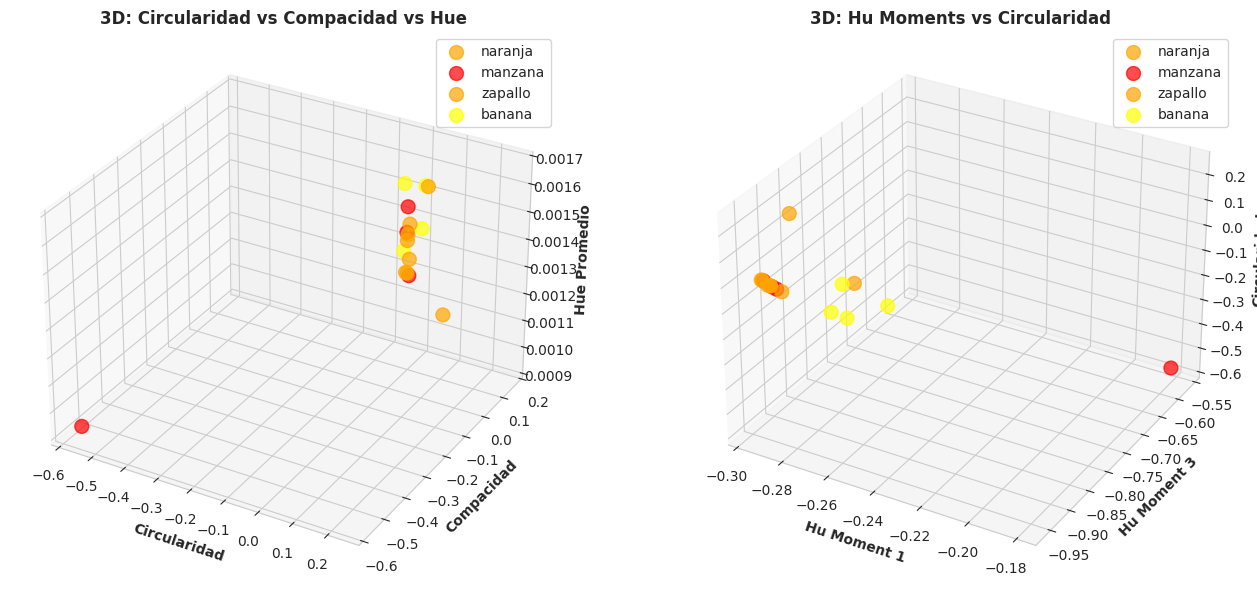

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# 3D scatter plot 1
ax1 = fig.add_subplot(121, projection='3d')
colors_dict = {'banana': 'yellow', 'manzana': 'red', 'naranja': 'orange', 'zapallo': 'orange'}

for fruit in data_simple['Fruta'].unique():
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    ax1.scatter(fruit_data['Circularidad'], fruit_data['Compacidad'], fruit_data['Hue_promedio'],
               label=fruit, s=100, alpha=0.7, color=colors_dict.get(fruit, 'gray'))

ax1.set_xlabel('Circularidad', fontweight='bold')
ax1.set_ylabel('Compacidad', fontweight='bold')
ax1.set_zlabel('Hue Promedio', fontweight='bold')
ax1.set_title('3D: Circularidad vs Compacidad vs Hue', fontweight='bold')
ax1.legend()

# 3D scatter plot 2
ax2 = fig.add_subplot(122, projection='3d')

for fruit in data_simple['Fruta'].unique():
    fruit_data = data_simple[data_simple['Fruta'] == fruit]
    ax2.scatter(fruit_data['Hu_1'], fruit_data['Hu_3'], fruit_data['Circularidad'],
               label=fruit, s=100, alpha=0.7, color=colors_dict.get(fruit, 'gray'))

ax2.set_xlabel('Hu Moment 1', fontweight='bold')
ax2.set_ylabel('Hu Moment 3', fontweight='bold')
ax2.set_zlabel('Circularidad', fontweight='bold')
ax2.set_title('3D: Hu Moments vs Circularidad', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 12. Conclusiones

**Resumen de observaciones:**

1. **Circularidad y Compacidad**: Son features opuestos y complementarios. Frutas redondas (naranja) tienen alta circularidad y baja compacidad, mientras que frutas alargadas (banana) tienen lo opuesto.

2. **Hu Moments**: Capturan características de forma que son invariantes a rotación y escala, útiles para diferenciar formas.

3. **Histogramas de Color (Hue y Saturación)**: Proporcionan información sobre el color y el nivel de saturación, permitiendo distinguir frutas por su coloración.

4. **Separabilidad**: El Silhouette Score indica qué tan bien pueden separarse las frutas usando estos features. Valores cercanos a 1 indican excelente separación.

5. **Vector Final**: Con 516 features (2 Hu + 256 Hue + 256 Saturación + Circularidad + Compacidad), el modelo K-Means tiene suficiente información para clasificar frutas con precisión.

## 13. Investigar el Pico en Hue=150 (Azul)

Analizando: /home/bruno/fing/IA_I/data/banana/banana1.jpg

Imagen original shape: (2304, 4096, 3)
Píxeles blancos (fondo) en máscara: 304
Píxeles blancos (fruta) en máscara invertida: 9436880


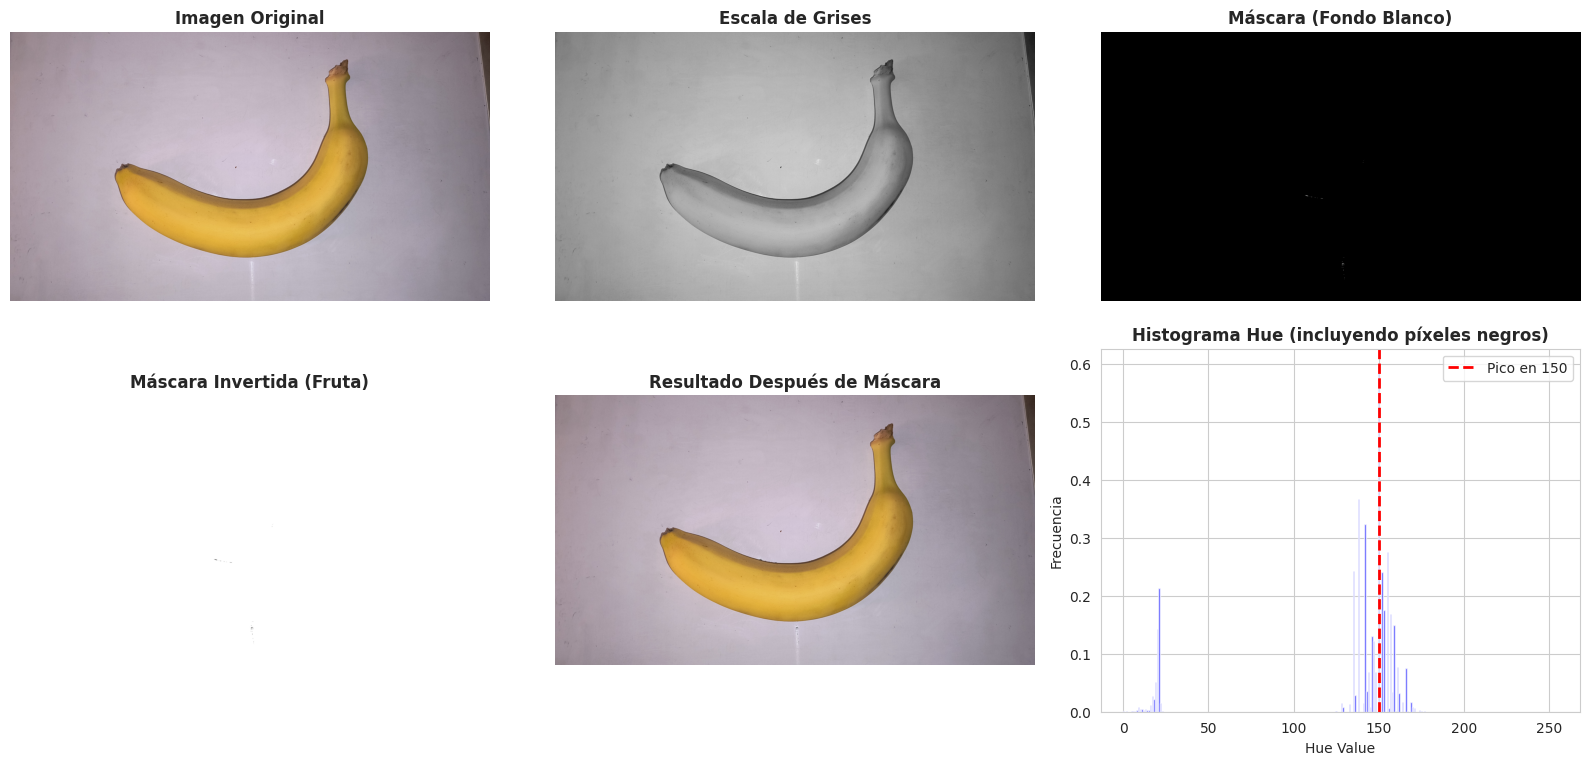


⚠️ PROBLEMA DETECTADO:
El histograma Hue está contando píxeles NEGROS (del fondo eliminado)
En HSV, los píxeles negros (0,0,0) se convierten a Hue=0
Pero también están los píxeles con baja saturación que pueden tener Hue=150

✅ SOLUCIÓN: Aplicar máscara al calcular histograma


In [ ]:
# Tomar la primera imagen de banana y ver el procesamiento paso a paso
banana_img_path = all_images[all_labels.index('banana')][0]
print(f"Analizando: {banana_img_path}\n")

# Leer imagen original
original = cv2.imread(banana_img_path)
print(f"Imagen original shape: {original.shape}")

# Paso 1: Convertir a escala de grises
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

# Paso 2: Crear máscara (umbral en 240 para detectar fondo blanco)
_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
print(f"Píxeles blancos (fondo) en máscara: {np.sum(mask == 255)}")

# Paso 3: Invertir máscara
mask_inv = cv2.bitwise_not(mask)
print(f"Píxeles blancos (fruta) en máscara invertida: {np.sum(mask_inv == 255)}")

# Paso 4: Aplicar máscara
result = cv2.bitwise_and(original, original, mask=mask_inv)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Convertir a HSV
hsv = cv2.cvtColor(result, cv2.COLOR_BGR2HSV)

# Visualizar
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Original
axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Imagen Original', fontweight='bold')
axes[0, 0].axis('off')

# Escala de grises
axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title('Escala de Grises', fontweight='bold')
axes[0, 1].axis('off')

# Máscara del fondo
axes[0, 2].imshow(mask, cmap='gray')
axes[0, 2].set_title('Máscara (Fondo Blanco)', fontweight='bold')
axes[0, 2].axis('off')

# Máscara invertida
axes[1, 0].imshow(mask_inv, cmap='gray')
axes[1, 0].set_title('Máscara Invertida (Fruta)', fontweight='bold')
axes[1, 0].axis('off')

# Resultado con máscara
axes[1, 1].imshow(result_rgb)
axes[1, 1].set_title('Resultado Después de Máscara', fontweight='bold')
axes[1, 1].axis('off')

# Histograma Hue SIN filtro de máscara
hist_hue_all = cv2.calcHist([hsv], [0], None, [256], (0, 256))
hist_hue_all = cv2.normalize(hist_hue_all, hist_hue_all).flatten()

axes[1, 2].bar(range(256), hist_hue_all, color='blue', alpha=0.7)
axes[1, 2].set_title('Histograma Hue (incluyendo píxeles negros)', fontweight='bold')
axes[1, 2].set_xlabel('Hue Value')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].axvline(x=150, color='red', linestyle='--', linewidth=2, label='Pico en 150')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\n⚠️ PROBLEMA DETECTADO:")
print("El histograma Hue está contando píxeles NEGROS (del fondo eliminado)")
print("En HSV, los píxeles negros (0,0,0) se convierten a Hue=0")
print("Pero también están los píxeles con baja saturación que pueden tener Hue=150")
print("\n✅ SOLUCIÓN: Aplicar máscara al calcular histograma")

## 14. Comparar: Histograma CON y SIN Máscara

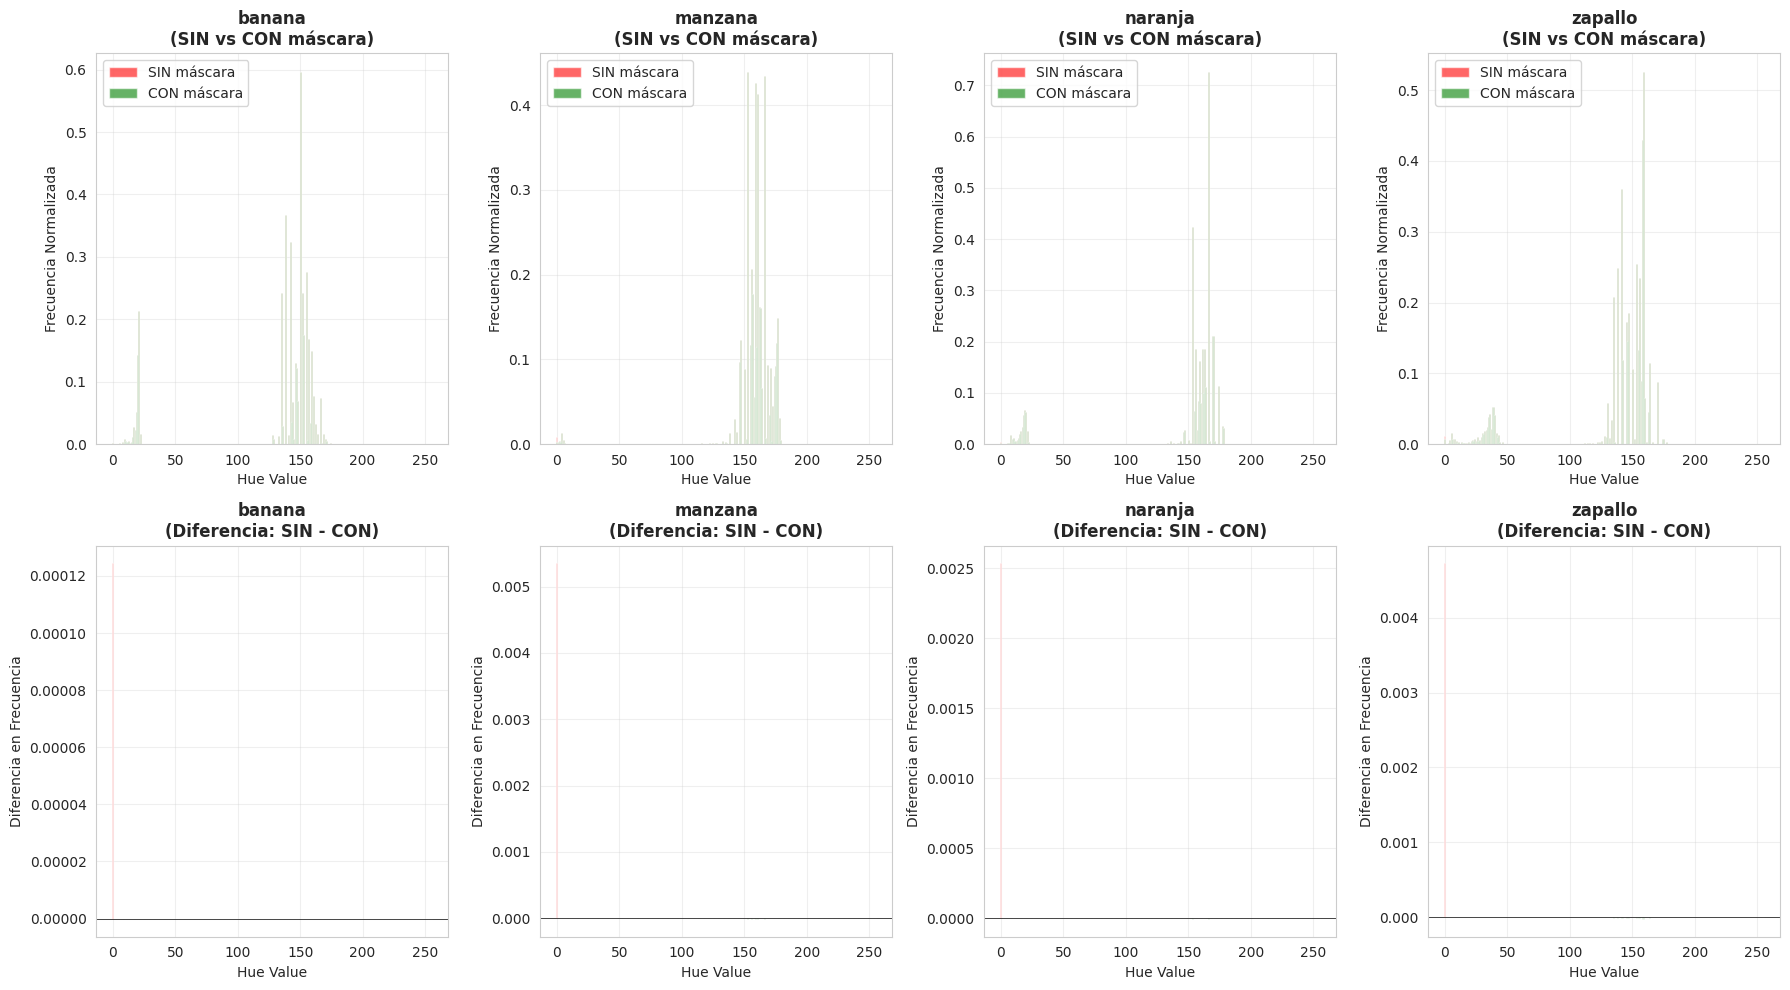

🔍 ANÁLISIS:
- Rojo: Área donde el histograma SIN máscara tiene más frecuencia (píxeles negros del fondo)
- Verde: Área donde el histograma CON máscara tiene más frecuencia (solo la fruta)

⚠️ CONCLUSIÓN: El pico en 150 (azul) viene del fondo NEGRO que no fue eliminado correctamente


In [ ]:
# Comparar histogramas CON y SIN máscara para todas las frutas
fig, axes = plt.subplots(2, len(fruit_folders), figsize=(18, 10))

fruits_sorted = sorted(fruit_folders.keys())

for idx, fruit in enumerate(fruits_sorted):
    # Obtener primera imagen de cada fruta
    fruit_img_path = os.path.join(base_folder, fruit, fruit_folders[fruit][0])
    
    # Procesar imagen
    original = cv2.imread(fruit_img_path)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    mask_inv = cv2.bitwise_not(mask)
    result = cv2.bitwise_and(original, original, mask=mask_inv)
    hsv = cv2.cvtColor(result, cv2.COLOR_BGR2HSV)
    
    # Histograma SIN máscara (método actual - incluye píxeles negros)
    hist_sin_mascara = cv2.calcHist([hsv], [0], None, [256], (0, 256))
    hist_sin_mascara = cv2.normalize(hist_sin_mascara, hist_sin_mascara).flatten()
    
    # Histograma CON máscara (método correcto - solo píxeles de fruta)
    hist_con_mascara = cv2.calcHist([hsv], [0], mask_inv, [256], (0, 256))
    hist_con_mascara = cv2.normalize(hist_con_mascara, hist_con_mascara).flatten()
    
    # Graficar
    ax1 = axes[0, idx]
    ax1.bar(range(256), hist_sin_mascara, color='red', alpha=0.6, label='SIN máscara')
    ax1.bar(range(256), hist_con_mascara, color='green', alpha=0.6, label='CON máscara')
    ax1.set_title(f'{fruit}\n(SIN vs CON máscara)', fontweight='bold')
    ax1.set_xlabel('Hue Value')
    ax1.set_ylabel('Frecuencia Normalizada')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de diferencia
    ax2 = axes[1, idx]
    diferencia = hist_sin_mascara - hist_con_mascara
    colors_diff = ['red' if d > 0 else 'green' for d in diferencia]
    ax2.bar(range(256), diferencia, color=colors_diff, alpha=0.7)
    ax2.set_title(f'{fruit}\n(Diferencia: SIN - CON)', fontweight='bold')
    ax2.set_xlabel('Hue Value')
    ax2.set_ylabel('Diferencia en Frecuencia')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("🔍 ANÁLISIS:")
print("- Rojo: Área donde el histograma SIN máscara tiene más frecuencia (píxeles negros del fondo)")
print("- Verde: Área donde el histograma CON máscara tiene más frecuencia (solo la fruta)")
print("\n⚠️ CONCLUSIÓN: El pico en 150 (azul) viene del fondo NEGRO que no fue eliminado correctamente")